# Отчёт

## Подготовка реестра ФНС для анализа

<pre>
Исходный реестр содержит сведения о субъектах предпринимательства.
Для анализа отберём юридические лица, относящиеся к малым и средним предприятиям,
с основным видом деятельности по ОКВЭД 41.20 «Строительство жилых и нежилых зданий».

Сначала загрузим исходный набор данных.
</pre>

In [127]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import geopandas as gpd
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from functools import lru_cache
from geopy.exc import GeocoderRateLimited

In [128]:
data = pd.read_excel("data/Реестр.xlsx", header=2, dtype={"ИНН": str, "ОГРН": str})
data.head(10)

/Users/a1111/Desktop/dz1/venv/lib/python3.14/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,№ п/п,Наименование / ФИО,Тип субъекта,Категория,ОГРН,ИНН,Основной вид деятельности,Регион,Район,Город,...,Дата исключения из реестра,Телефон,E-mail,WWW,Наличие лицензий,"Наличие заключенных договоров, контрактов","Производство инновационной, высокотехнологичной продукции",Участие в программах партнерства,Является социальным предприятием,Среднесписочная численность работников за предшествующий календарный год
0,1,""" МЕГАПОЛИС "" ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВ...",Юридическое лицо,Не является субъектом МСП,1027800523376,7801190028,41.2 Строительство жилых и нежилых зданий,78 - г.Санкт-Петербург,NaN,NaN,...,10.10.2021,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,NaN
1,2,""" СТАЛЬИНВЕСТСТРОЙ "" ОБЩЕСТВО С ОГРАНИЧЕННОЙ О...",Юридическое лицо,Не является субъектом МСП,1037800033545,7801227976,41.20 Строительство жилых и нежилых зданий,78 - г.Санкт-Петербург,NaN,NaN,...,10.08.2018,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,NaN
2,3,""" СТРОЙТЕХНИКА - М "" ОБЩЕСТВО С ОГРАНИЧЕННОЙ О...",Юридическое лицо,Не является субъектом МСП,1025204418293,5263039399,41.20 Строительство жилых и нежилых зданий,52 - Нижегородская область,NaN,г Нижний Новгород,...,10.07.2022,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,NaN
3,4,"""БАЗИС"" ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ",Юридическое лицо,Микропредприятие,1025204411682,5263025484,41.20 Строительство жилых и нежилых зданий,52 - Нижегородская область,NaN,г Нижний Новгород,...,NaN,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,1.0
4,5,"""БЕЛАГ"" ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ",Юридическое лицо,Не является субъектом МСП,1037800039276,7801123215,41.20 Строительство жилых и нежилых зданий,78 - г.Санкт-Петербург,NaN,NaN,...,10.07.2021,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,NaN
5,6,"""БЕРЕГ"" ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ",Юридическое лицо,Микропредприятие,1035010950633,5056003490,41.20 Строительство жилых и нежилых зданий,50 - Московская область,NaN,г Люберцы,...,NaN,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,2.0
6,7,"""БРИГ-С"" ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ",Юридическое лицо,Микропредприятие,1022501801343,2537042746,41.20 Строительство жилых и нежилых зданий,25 - Приморский край,NaN,г Владивосток,...,NaN,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,1.0
7,8,"""ВИВО"" ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ",Юридическое лицо,Не является субъектом МСП,1037800022842,7801201350,41.20 Строительство жилых и нежилых зданий,78 - г.Санкт-Петербург,NaN,NaN,...,10.05.2020,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,NaN
8,9,"""ВИРАЖ-2000"" ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕ...",Юридическое лицо,Микропредприятие,1022501797768,2537036693,41.20 Строительство жилых и нежилых зданий,25 - Приморский край,NaN,г Владивосток,...,NaN,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,3.0
9,10,"""ВОССТАНОВЛЕНИЕ"" ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТ...",Юридическое лицо,Не является субъектом МСП,1025204410307,5263011749,41.20 Строительство жилых и нежилых зданий,52 - Нижегородская область,NaN,г Нижний Новгород,...,10.04.2023,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,NaN


In [129]:
data['Среднесписочная численность работников за предшествующий календарный год'] = data['Среднесписочная численность работников за предшествующий календарный год'].astype('Int64')
data['Среднесписочная численность работников за предшествующий календарный год'] = data['Среднесписочная численность работников за предшествующий календарный год'].fillna(0)
data.dtypes


№ п/п                                                                       int64
Наименование / ФИО                                                            str
Тип субъекта                                                                  str
Категория                                                                     str
ОГРН                                                                          str
ИНН                                                                           str
Основной вид деятельности                                                     str
Регион                                                                        str
Район                                                                         str
Город                                                                         str
Населенный пункт                                                              str
Вновь созданный                                                               str
Дата включения в

---

## Формирование выборки с помощью фильтрации

In [130]:

current_df = data[(data['Тип субъекта'] == 'Юридическое лицо') & ((data['Категория'] == 'Малое предприятие') | (data['Категория'] == 'Среднее предприятие')) &  (data['Основной вид деятельности'] == '41.20 Строительство жилых и нежилых зданий')] 
current_df.shape

(8927, 23)

In [131]:
current_df

,№ п/п,Наименование / ФИО,Тип субъекта,Категория,ОГРН,ИНН,Основной вид деятельности,Регион,Район,Город,...,Дата исключения из реестра,Телефон,E-mail,WWW,Наличие лицензий,"Наличие заключенных договоров, контрактов","Производство инновационной, высокотехнологичной продукции",Участие в программах партнерства,Является социальным предприятием,Среднесписочная численность работников за предшествующий календарный год
19,20,"""КОРПОРАЦИЯ ВИТ"" (ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕ...",Юридическое лицо,Малое предприятие,1025004907080,5038038838,41.20 Строительство жилых и нежилых зданий,50 - Московская область,Пушкино г,NaN,...,NaN,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,36
51,52,"""ХОЗРАСЧЕТНАЯ СТРОИТЕЛЬНО-ТЕХНОЛОГИЧЕСКАЯ ФИРМ...",Юридическое лицо,Среднее предприятие,1025007270551,5027006369,41.20 Строительство жилых и нежилых зданий,50 - Московская область,NaN,г Дзержинский,...,NaN,NaN,NaN,NaN,Да,Нет,Нет,Нет,Нет,201
4652,4653,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""777""",Юридическое лицо,Малое предприятие,1021400692048,1414006922,41.20 Строительство жилых и нежилых зданий,77 - г.Москва,NaN,NaN,...,NaN,NaN,NaN,NaN,Да,Нет,Нет,Нет,Нет,35
4667,4668,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АГРОТЕХИМПОРТ""",Юридическое лицо,Малое предприятие,1043301806415,3327332190,41.20 Строительство жилых и нежилых зданий,33 - Владимирская область,NaN,г Владимир,...,NaN,NaN,NaN,NaN,Да,Нет,Нет,Нет,Нет,52
4673,4674,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АКС""",Юридическое лицо,Малое предприятие,1027807999988,7816061297,41.20 Строительство жилых и нежилых зданий,78 - г.Санкт-Петербург,NaN,NaN,...,NaN,NaN,NaN,NaN,Да,Нет,Нет,Нет,Нет,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
560511,560512,"СМУ ""МОНОЛИТ"" (ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТ...",Юридическое лицо,Малое предприятие,1162301050515,2301091157,41.20 Строительство жилых и нежилых зданий,23 - Краснодарский край,Анапский р-н,г Анапа,...,NaN,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,4
560512,560513,"СМУ ""РУСЬ"" (ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕН...",Юридическое лицо,Малое предприятие,1132301002900,2301083597,41.20 Строительство жилых и нежилых зданий,23 - Краснодарский край,Анапский р-н,г Анапа,...,NaN,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,74
560902,560903,СОВМЕСТНОЕ ПРЕДПРИЯТИЕ ОБЩЕСТВО С ОГРАНИЧЕННОЙ...,Юридическое лицо,Среднее предприятие,1026500785673,6504043928,41.20 Строительство жилых и нежилых зданий,65 - Сахалинская область,Корсаковский р-н,г Корсаков,...,NaN,NaN,NaN,NaN,Да,Нет,Нет,Нет,Нет,145
580132,580133,"ФИРМА ""ТЕПЛОСТРОЙПРОЕКТ-С"" ОБЩЕСТВО С ОГРАНИЧЕ...",Юридическое лицо,Малое предприятие,1032000400233,2002001476,41.20 Строительство жилых и нежилых зданий,20 - Чеченская Республика,Ачхой-Мартановский р-н,NaN,...,NaN,NaN,NaN,NaN,Да,Нет,Нет,Нет,Нет,67


---

## Подготовка списка компаний для сбора данных

Для этого получим уникальные значения ИНН.

In [132]:
current_df["ИНН"].unique()

<StringArray>
['5038038838', '5027006369', '1414006922', '3327332190', '7816061297',
 '3525048992', '3101000612', '5902126804', '0523005733', '5009106346',
 ...
 '0268085030', '7448002395', '6506011671', '5751005940', '2010001470',
 '2301091157', '2301083597', '6504043928', '2002001476', '0702005585']
Length: 8927, dtype: str

Количество уникальных ИНН совпадает с количеством строк в выборке. Следовательно, каждому ИНН соответствует одна строка.

---

## Получение данных с сайта bo.nalog.gov.ru для расчёта EBIT

<pre>
EBIT — показатель прибыли до вычета процентов и налога на прибыль.
В этом отчёте используем следующую формулу:

EBIT = прибыль до налогообложения + проценты к уплате.

Положительное значение означает, что рассчитанный результат превышает ноль,
отрицательное — что он ниже нуля.
Рост показателя отражает увеличение результата по выбранной формуле, снижение — его уменьшение.
При этом показатель может включать прочие доходы и расходы, поэтому его изменение
не обязательно означает улучшение или ухудшение результатов основной деятельности.

Для сравнения компаний разного размера также рассчитаем EBIT margin:

EBIT margin = EBIT / Выручка × 100%.

Если необходимые данные отсутствуют или выручка равна нулю, маржинальность не рассчитывается.
</pre>

In [133]:
session = requests.Session()

session.headers.update({
    "User-Agent": "Mozilla/5.0",
    "Accept": "application/json",
    "Referer": "https://bo.nalog.gov.ru/",
})

def get_company_financials(INN, session):
    res = session.get(
        'https://bo.nalog.gov.ru/advanced-search/organizations/search',
        params={'query': INN, 'page': 0},
        timeout=30
    )

    res.raise_for_status()

    company = res.json()

    company_org_id = company['content'][0]['id']

    sres = session.get(
        f'https://bo.nalog.gov.ru/nbo/organizations/{company_org_id}/bfo',
        timeout=30
    )

    sres.raise_for_status()

    reports = sres.json()

    rows = []

    for report in reports:
        financial = (
            report["typeCorrections"][0]["correction"].get("financialResult")
            or {}
        )

        rows.append({
            'inn': INN,
            'year': report['period'],
            'revenue': financial.get('current2110'),
            'profit_before_tax': financial.get('current2300'),
            'interest_expense': financial.get('current2330'),
            'net_profit': financial.get('current2400'),
        })

        row = rows[-1]
        profit = row["profit_before_tax"]
        interest = row["interest_expense"]
        revenue = row["revenue"]

        row["ebit"] = (
            profit + interest
            if profit is not None and interest is not None
            else None
        )

        row["ebit_margin"] = (
            round(row["ebit"] / revenue * 100, 2)
        if row["ebit"] is not None and revenue not in (None, 0)
        else None
        )

    return rows

get_company_financials('7816061297', session)

[{'inn': '7816061297',
  'year': '2023',
  'revenue': 116186.0,
  'profit_before_tax': None,
  'interest_expense': 0.0,
  'net_profit': 565.0,
  'ebit': None,
  'ebit_margin': None},
 {'inn': '7816061297',
  'year': '2022',
  'revenue': 61921.0,
  'profit_before_tax': 565.0,
  'interest_expense': 9.0,
  'net_profit': 444.0,
  'ebit': 574.0,
  'ebit_margin': 0.93},
 {'inn': '7816061297',
  'year': '2021',
  'revenue': 179874.0,
  'profit_before_tax': 1385.0,
  'interest_expense': 0.0,
  'net_profit': 1077.0,
  'ebit': 1385.0,
  'ebit_margin': 0.77},
 {'inn': '7816061297',
  'year': '2025',
  'revenue': 288686.0,
  'profit_before_tax': None,
  'interest_expense': None,
  'net_profit': 2542.0,
  'ebit': None,
  'ebit_margin': None},
 {'inn': '7816061297',
  'year': '2024',
  'revenue': 782668.0,
  'profit_before_tax': None,
  'interest_expense': None,
  'net_profit': 11674.0,
  'ebit': None,
  'ebit_margin': None}]

<pre>
По ИНН получим информацию о компании через API сайта ФНС.
Из результата поиска извлечём внутренний идентификатор компании (id),
по которому запросим её бухгалтерскую отчётность.

Функция принимает ИНН компании и сессию requests.Session.
Она возвращает показатели отчётности по годам, рассчитанные EBIT и EBIT margin,
а также данные для дальнейшего анализа и построения графиков.
Если исходные показатели отсутствуют, соответствующие расчётные значения остаются пустыми.
</pre>

---

In [134]:
all_rows = []

for inn in current_df['ИНН'][:1000].dropna().astype(str).unique():
    try:
        rows = get_company_financials(inn, session)
        all_rows.extend(rows)

    except Exception as e:
        print(f'Ошибка для {inn}: {e}')

financial_df = pd.DataFrame(all_rows)
financial_df = financial_df.rename(columns={
    'inn': 'ИНН',
    'profit_before_tax': 'Прибыль до налога',
    'interest_expense': 'Проценты к уплате',
    'revenue': 'Выручка',
    'net_profit': 'Чистая прибыль',
    'year': 'Год',
    'ebit': 'EBIT',
    'ebit_margin': "EBIT/MARGIN (%)"
    
})
financial_df

Ошибка для 5009106346: list index out of range
Ошибка для 5032261607: list index out of range
Ошибка для 9703026866: list index out of range
Ошибка для 9704117273: list index out of range
Ошибка для 7720866131: list index out of range


,ИНН,Год,Выручка,Прибыль до налога,Проценты к уплате,Чистая прибыль,EBIT,EBIT/MARGIN (%)
0,5038038838,2023,108966.0,-20665.0,3334.0,-20913.0,-17331.0,-15.90
1,5038038838,2021,184044.0,3430.0,5601.0,3080.0,9031.0,4.91
2,5038038838,2024,112540.0,-19938.0,1521.0,-20129.0,-18417.0,-16.36
3,5038038838,2022,118633.0,20219.0,141.0,19518.0,20360.0,17.16
4,5038038838,2025,140064.0,-457.0,11869.0,-520.0,11412.0,8.15
...,...,...,...,...,...,...,...,...
4571,7813281657,2025,88331.0,NaN,2124.0,3669.0,NaN,NaN
4572,7813281657,2023,214427.0,NaN,NaN,24782.0,NaN,NaN
4573,7813281657,2024,248095.0,NaN,NaN,41506.0,NaN,NaN
4574,7813281657,2021,175471.0,NaN,NaN,7944.0,NaN,NaN


In [135]:
merge_date = current_df.merge(
    financial_df,
    on='ИНН',
    how='right'
)

merge_date.shape


(4576, 30)

<pre>
Объединив сведения из Excel с финансовыми данными, полученными через API ФНС,
мы сформировали таблицу для дальнейшего анализа.
Каждая строка объединяет сведения о компании и показатели за соответствующий отчётный год.
Для отдельных компаний и лет часть финансовых показателей отсутствует.
</pre>

In [136]:
by_year = merge_date.groupby("Год").agg(
    total_revenue=("Выручка", lambda x: x.sum(min_count=1)),
    total_ebit=("EBIT", lambda x: x.sum(min_count=1)),
    median_ebit=("EBIT", "median"),
    mean_ebit=("EBIT", "mean"),
).round(2)

by_year

,total_revenue,total_ebit,median_ebit,mean_ebit
Год,,,,
2021,247681703.0,8883736.0,6783.5,29416.34
2022,273146733.0,6981662.0,8777.0,23747.15
2023,325002233.0,16493082.0,8357.0,56872.70
2024,339371326.0,11953776.0,11696.0,41650.79
2025,327088990.0,18538586.0,7416.0,52967.39


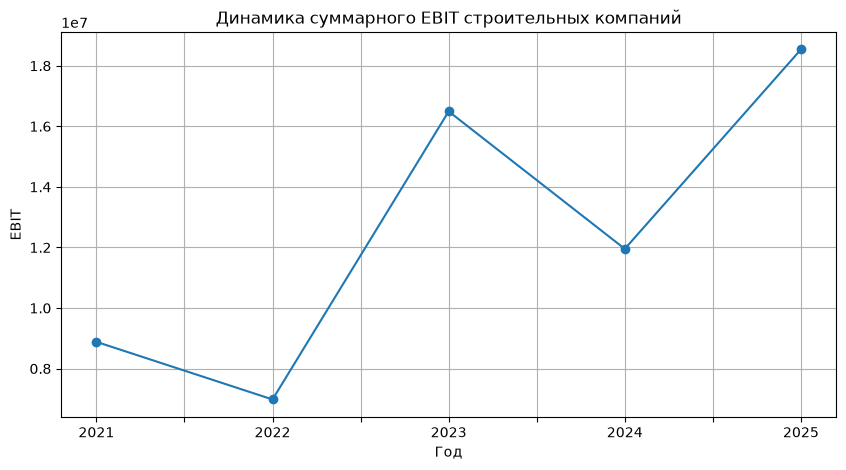

In [137]:
by_year['total_ebit'].plot(
    kind='line',
    marker='o',
    figsize=(10, 5)
)
plt.title('Динамика суммарного EBIT строительных компаний')
plt.xlabel('Год')
plt.ylabel('EBIT')
plt.grid()
plt.show()

<pre>
Суммарный EBIT компаний с доступными данными менялся неравномерно:
снижался в 2022 и 2024 годах и рос в 2023 и 2025 годах.
Максимальное значение достигнуто в 2025 году. Устойчивого ежегодного роста не наблюдается.
При сравнении лет необходимо учитывать изменения состава компаний с доступными данными.
</pre>

Text(0, 0.5, 'Суммарная выручка')

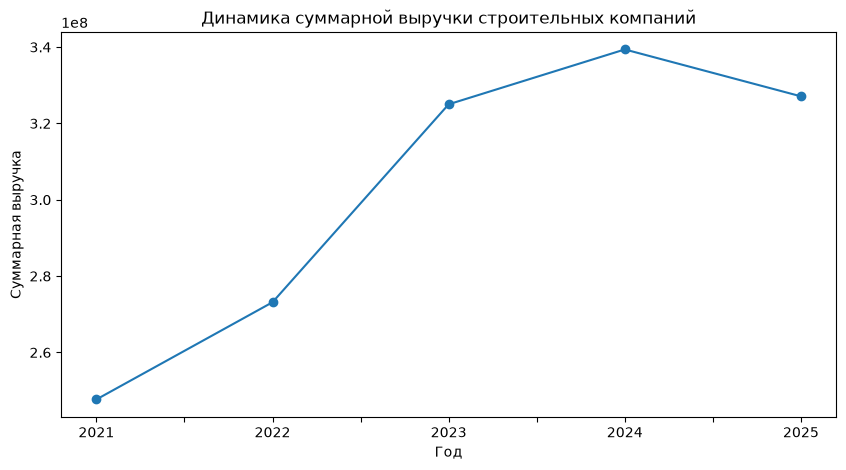

In [138]:
by_year['total_revenue'].plot(
    kind='line',
    marker='o',
    figsize=(10, 5)
)

plt.title('Динамика суммарной выручки строительных компаний')
plt.xlabel('Год')
plt.ylabel('Суммарная выручка')

<pre>
Суммарная выручка компаний выборки росла с 2021 по 2024 год.
В 2025 году она снизилась примерно на 3,6%, но осталась выше уровня 2021 года.
Эта динамика относится к собранным данным и не характеризует всю строительную отрасль.
</pre>

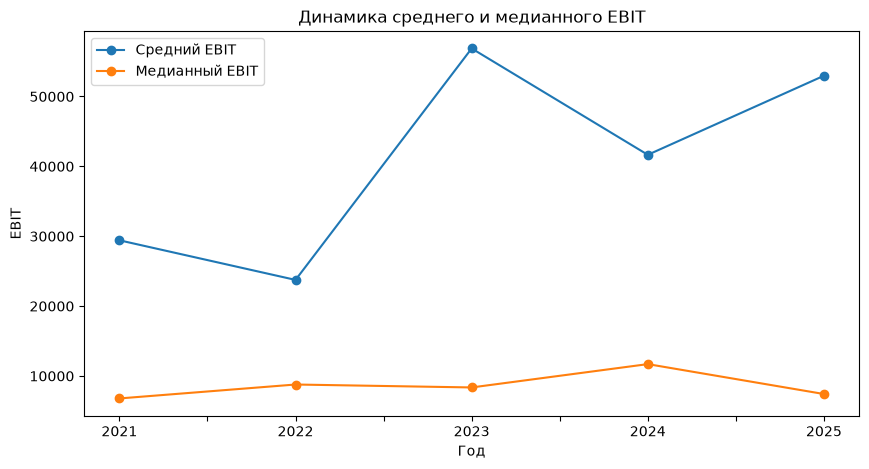

In [139]:
by_year[['mean_ebit', 'median_ebit']].plot(
    kind='line',
    marker='o',
    figsize=(10, 5)
)

plt.title('Динамика среднего и медианного EBIT')
plt.xlabel('Год')
plt.ylabel('EBIT')
plt.legend(['Средний EBIT', 'Медианный EBIT'])

<pre>
Средний EBIT во все годы значительно выше медианного:
высокие результаты отдельных компаний заметно повышают среднее значение.
В 2025 году средний EBIT вырос, а медианный снизился.
Следовательно, рост среднего показателя не означает улучшения результатов большинства компаний.
</pre>

In [140]:
by_inn = financial_df[['ИНН', 'Чистая прибыль', 'Год']]
by_inn_persent = by_inn.pivot(
    index='ИНН',
    columns='Год',
    values='Чистая прибыль'
)


In [141]:
by_inn_persent = by_inn_persent[
    (by_inn_persent['2022'] > 0) &
    (by_inn_persent['2024'].notna())
]

by_inn_persent['growth_percent'] = (
    (by_inn_persent['2024'] - by_inn_persent['2022'])
    / by_inn_persent['2022']
    * 100
)
by_inn_persent['growth_percent'] = by_inn_persent['growth_percent'].round()
by_inn_persent

Год,2021,2022,2023,2024,2025,growth_percent
ИНН,,,,,,
0101009232,2061.0,15572.0,20041.0,14461.0,32194.0,-7.0
0262002911,6856.0,1866.0,30056.0,-2756.0,-74387.0,-248.0
0273068738,3749.0,3323.0,547.0,714.0,842.0,-79.0
0273092508,214.0,718.0,118.0,624.0,878.0,-13.0
0274168157,434.0,951.0,1219.0,902.0,-4415.0,-5.0
...,...,...,...,...,...,...
9722013742,NaN,45844.0,1981.0,8207.0,4333.0,-82.0
9723043933,257.0,1253.0,2644.0,1593.0,2918.0,27.0
9726005076,NaN,14314.0,20187.0,29629.0,11446.0,107.0


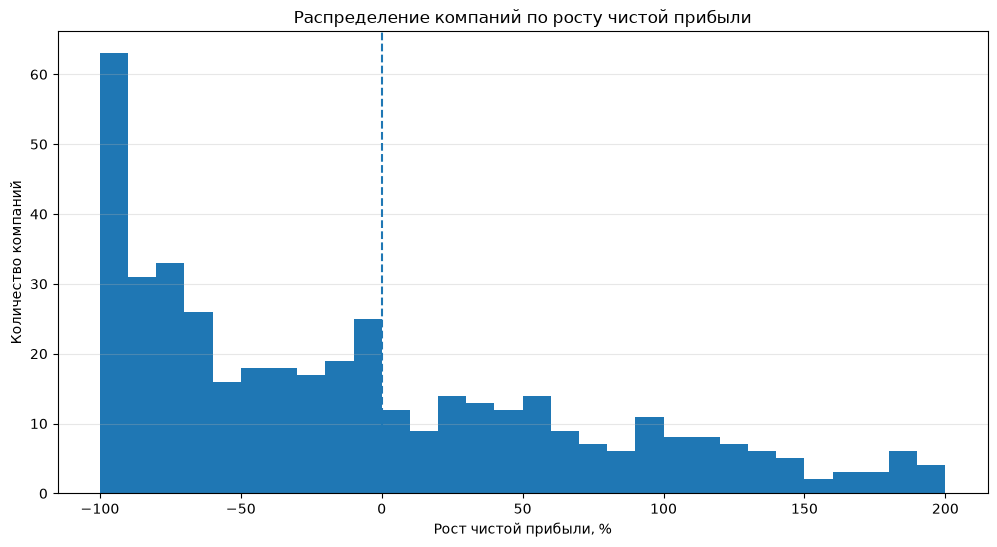

In [142]:
graph_df = (
    by_inn_persent
    .groupby('growth_percent')
    .size()
    .reset_index(name='company_count')
)
graph_df['growth_percent'] = graph_df['growth_percent'].round()

graph_data = by_inn_persent[
    by_inn_persent['growth_percent'].between(-100, 200)
]

plt.figure(figsize=(12, 6))

plt.hist(
    graph_data['growth_percent'],
    bins=30
)
plt.axvline(0, linestyle='--')
plt.title('Распределение компаний по росту чистой прибыли')
plt.xlabel('Рост чистой прибыли, %')
plt.ylabel('Количество компаний')
plt.grid(axis='y', alpha=0.3)

plt.show()



<pre>
На показанном участке распределения больше компаний со снижением чистой прибыли, чем с её ростом.
Самый высокий столбец соответствует снижению примерно на 90–100%.
При этом есть компании, у которых чистая прибыль выросла более чем вдвое.

Гистограмма показывает изменение чистой прибыли за 2022–2024 годы.
В неё включены только компании с положительной чистой прибылью в 2022 году,
известным значением за 2024 год и изменением от −100% до +200%.
Остальные наблюдения на графике не представлены.
</pre>

## Топ-500 компаний выборки по выручке за последний доступный год на карте

In [151]:
last_year = financial_df['Год'].max()

sort_financial_df = (
    financial_df[financial_df['Год'] == last_year]
    .nlargest(500, 'Выручка')
)
sort_financial_df = sort_financial_df.head(500)
sort_financial_df_merge = pd.merge(sort_financial_df, data, on='ИНН')
sort_financial_df_merge = sort_financial_df_merge[['ИНН', 'Наименование / ФИО', 'Выручка', 'Регион','Город']]
sort_financial_df_merge

,ИНН,Наименование / ФИО,Выручка,Регион,Город
0,9717108903,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""АИР ...",7211988.0,77 - г.Москва,NaN
1,7712103721,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""ТЕПЛОИНДУСТРИЯ""",6079192.0,77 - г.Москва,NaN
2,1655211533,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""АПЕКС""",5934378.0,16 - Республика Татарстан (Татарстан),г Казань
3,7816300957,"АКЦИОНЕРНОЕ ОБЩЕСТВО СТРОИТЕЛЬНАЯ КОМПАНИЯ ""КО...",5849564.0,78 - г.Санкт-Петербург,NaN
4,7806056530,"ЗАКРЫТОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО ""СТРОИТЕЛЬНАЯ КО...",5744991.0,78 - г.Санкт-Петербург,NaN
...,...,...,...,...,...
495,1510008048,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""МОЗДОКСКАЯ ПЕРЕДВИЖНАЯ М...",77748.0,15 - Республика Северная Осетия - Алания,г Моздок
496,7838408009,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""СТР...",77567.0,78 - г.Санкт-Петербург,NaN
497,3443129023,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""АСТР...",76998.0,34 - Волгоградская область,г Волгоград
498,5030048672,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""АГРО...",76765.0,77 - г.Москва,NaN


In [152]:
region = (
    sort_financial_df_merge["Регион"]
    .fillna("")
    .str.replace(r"^\s*\d+\s*-\s*", "", regex=True)
)

city = sort_financial_df_merge["Город"].fillna("")

sort_financial_df_merge["location"] = (
    city + ", " + region
).str.strip(", ") + ", Россия"
sort_financial_df_merge

,ИНН,Наименование / ФИО,Выручка,Регион,Город,location
0,9717108903,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""АИР ...",7211988.0,77 - г.Москва,NaN,"г.Москва, Россия"
1,7712103721,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""ТЕПЛОИНДУСТРИЯ""",6079192.0,77 - г.Москва,NaN,"г.Москва, Россия"
2,1655211533,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""АПЕКС""",5934378.0,16 - Республика Татарстан (Татарстан),г Казань,"г Казань, Республика Татарстан (Татарстан), Ро..."
3,7816300957,"АКЦИОНЕРНОЕ ОБЩЕСТВО СТРОИТЕЛЬНАЯ КОМПАНИЯ ""КО...",5849564.0,78 - г.Санкт-Петербург,NaN,"г.Санкт-Петербург, Россия"
4,7806056530,"ЗАКРЫТОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО ""СТРОИТЕЛЬНАЯ КО...",5744991.0,78 - г.Санкт-Петербург,NaN,"г.Санкт-Петербург, Россия"
...,...,...,...,...,...,...
495,1510008048,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""МОЗДОКСКАЯ ПЕРЕДВИЖНАЯ М...",77748.0,15 - Республика Северная Осетия - Алания,г Моздок,"г Моздок, Республика Северная Осетия - Алания,..."
496,7838408009,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""СТР...",77567.0,78 - г.Санкт-Петербург,NaN,"г.Санкт-Петербург, Россия"
497,3443129023,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""АСТР...",76998.0,34 - Волгоградская область,г Волгоград,"г Волгоград, Волгоградская область, Россия"
498,5030048672,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""АГРО...",76765.0,77 - г.Москва,NaN,"г.Москва, Россия"


In [153]:
geolocator = Nominatim(user_agent='construction_market_analysis', timeout=30)


geocode = RateLimiter(
    geolocator.geocode,
    min_delay_seconds=2,
    max_retries=0,
    swallow_exceptions=False,
)
@lru_cache(maxsize=None)
def get_coordinates(location):
    geo = geocode(location)
    if geo is None:
        return None, None

    return geo.latitude, geo.longitude


cords = sort_financial_df_merge["location"].apply(get_coordinates)



In [ ]:
sort_financial_df_merge[['latitude', 'longitude']] = pd.DataFrame(
    cords.tolist(),
    index=sort_financial_df_merge.index
)
sort_financial_df_merge

,ИНН,Наименование / ФИО,Выручка,Регион,Город,location,latitude,longitude
0,9717108903,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""АИР ...",7211988.0,77 - г.Москва,NaN,"Москва, Россия",55.625578,37.606392
1,7712103721,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""ТЕПЛОИНДУСТРИЯ""",6079192.0,77 - г.Москва,NaN,"Москва, Россия",55.625578,37.606392
2,1655211533,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""АПЕКС""",5934378.0,16 - Республика Татарстан (Татарстан),г Казань,г Казань 16 - Республика Татарстан (Татарстан)...,55.731007,49.174354
3,7816300957,"АКЦИОНЕРНОЕ ОБЩЕСТВО СТРОИТЕЛЬНАЯ КОМПАНИЯ ""КО...",5849564.0,78 - г.Санкт-Петербург,NaN,"Санкт-Петербург, Россия",59.960674,30.158655
4,7806056530,"ЗАКРЫТОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО ""СТРОИТЕЛЬНАЯ КО...",5744991.0,78 - г.Санкт-Петербург,NaN,"Санкт-Петербург, Россия",59.960674,30.158655
...,...,...,...,...,...,...,...,...
495,1510008048,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""МОЗДОКСКАЯ ПЕРЕДВИЖНАЯ М...",77748.0,15 - Республика Северная Осетия - Алания,г Моздок,г Моздок 15 - Республика Северная Осетия - Ала...,NaN,NaN
496,7838408009,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""СТР...",77567.0,78 - г.Санкт-Петербург,NaN,"Санкт-Петербург, Россия",59.960674,30.158655
497,3443129023,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""АСТР...",76998.0,34 - Волгоградская область,г Волгоград,"г Волгоград 34 - Волгоградская область, Россия",48.693585,44.340413
498,5030048672,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""АГРО...",76765.0,77 - г.Москва,NaN,"Москва, Россия",55.625578,37.606392


In [ ]:
geo_df = sort_financial_df_merge.dropna(
    subset=['latitude', 'longitude']
).copy()

geo_df.shape


(460, 8)

In [ ]:
gdf = gpd.GeoDataFrame(
    geo_df,
    geometry=gpd.points_from_xy(
        geo_df['longitude'],
        geo_df['latitude']
    ),
    crs='EPSG:4326'
)

In [ ]:
gdf

,ИНН,Наименование / ФИО,Выручка,Регион,Город,location,latitude,longitude,geometry
0,9717108903,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""АИР ...",7211988.0,77 - г.Москва,NaN,"Москва, Россия",55.625578,37.606392,POINT (37.60639 55.62558)
1,7712103721,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""ТЕПЛОИНДУСТРИЯ""",6079192.0,77 - г.Москва,NaN,"Москва, Россия",55.625578,37.606392,POINT (37.60639 55.62558)
2,1655211533,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""АПЕКС""",5934378.0,16 - Республика Татарстан (Татарстан),г Казань,г Казань 16 - Республика Татарстан (Татарстан)...,55.731007,49.174354,POINT (49.17435 55.73101)
3,7816300957,"АКЦИОНЕРНОЕ ОБЩЕСТВО СТРОИТЕЛЬНАЯ КОМПАНИЯ ""КО...",5849564.0,78 - г.Санкт-Петербург,NaN,"Санкт-Петербург, Россия",59.960674,30.158655,POINT (30.15866 59.96067)
4,7806056530,"ЗАКРЫТОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО ""СТРОИТЕЛЬНАЯ КО...",5744991.0,78 - г.Санкт-Петербург,NaN,"Санкт-Петербург, Россия",59.960674,30.158655,POINT (30.15866 59.96067)
...,...,...,...,...,...,...,...,...,...
494,5407263443,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ "" СИБ...",78602.0,54 - Новосибирская область,г Новосибирск,"г Новосибирск 54 - Новосибирская область, Россия",55.014289,82.892373,POINT (82.89237 55.01429)
496,7838408009,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""СТР...",77567.0,78 - г.Санкт-Петербург,NaN,"Санкт-Петербург, Россия",59.960674,30.158655,POINT (30.15866 59.96067)
497,3443129023,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""АСТР...",76998.0,34 - Волгоградская область,г Волгоград,"г Волгоград 34 - Волгоградская область, Россия",48.693585,44.340413,POINT (44.34041 48.69359)
498,5030048672,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""АГРО...",76765.0,77 - г.Москва,NaN,"Москва, Россия",55.625578,37.606392,POINT (37.60639 55.62558)


In [ ]:
world = gpd.read_file('./ne_50m_admin_0_countries.geojson')
russia = world[world['ADMIN'] == 'Russia']


,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
75,Admin-0 country,5,2,Russia,RUS,0,2,Sovereign country,1,Russia,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((145.88154 43.45952, 145.8956 4..."


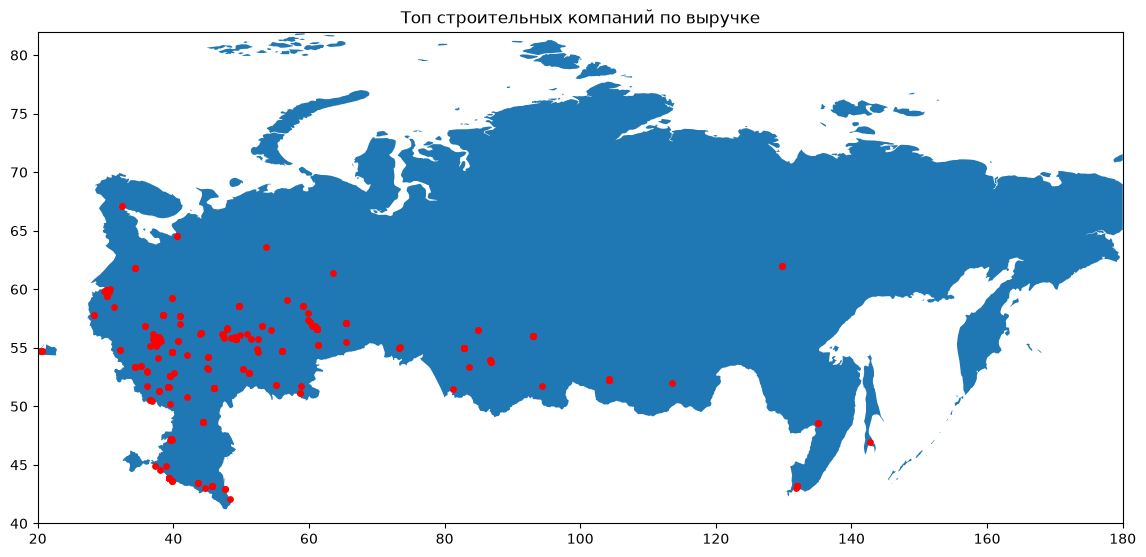

In [ ]:
fig, ax = plt.subplots(figsize=(14, 8))

russia.plot(ax=ax)

gdf.plot(
    ax=ax,
    color='red',
    markersize=15
)

ax.set_xlim(20, 180)
ax.set_ylim(40, 82)

plt.title('Топ строительных компаний по выручке')
plt.show()